In [1]:
# Data manipulation
import os
import io
import requests
import numpy as np
import pandas as pd

# Statistics
from scipy import stats
from scipy.stats import linregress, pearsonr

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import YearLocator, DateFormatter

In [2]:
'#491212FF, #F27127FF, #F24C27FF, #BF281BFF, #CE471CFF #171E15FF, #32373AFF, #5E5752FF, #9F9994FF, #CCC2B5FF, #E8CFABFF, #F5BC5CFF, #E2853AFF, #CC4C24FF, #3F1606FF '

'#491212FF, #F27127FF, #F24C27FF, #BF281BFF, #CE471CFF #171E15FF, #32373AFF, #5E5752FF, #9F9994FF, #CCC2B5FF, #E8CFABFF, #F5BC5CFF, #E2853AFF, #CC4C24FF, #3F1606FF '

# Cherry Picking

In [3]:
# ---- Load data ----
url = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt"
text = requests.get(url).text
header_lines = [line for line in text.splitlines() if line.startswith("%")]
numeric_lines = [
    line for line in text.splitlines()
    if not line.startswith("%") and not line.startswith("#") and line.strip() != ""
]

df_data = pd.read_csv(
    io.StringIO("\n".join(numeric_lines)),
    sep=r"\s+",
    engine="python",
    header=None
)

df_data.columns = [
    "Year", "month", "month_Anomaly", "Monthly_Unc",
    "Annual_Anomaly", "Annual_Unc",
    "5_Anomaly", "5__Unc",
    "10_Anomaly", "10__Unc",
    "20_Anomaly", "20__Unc"
]

df_data["Date"] = pd.to_datetime(df_data[["Year", "month"]].assign(DAY=1))
df_data = df_data[['Year', 'month', 'month_Anomaly', 'Monthly_Unc', 'Date']]
df_data

,Year,month,month_Anomaly,Monthly_Unc,Date
0,1850,1,-0.753,0.365,1850-01-01
1,1850,2,-0.202,0.416,1850-02-01
2,1850,3,-0.367,0.373,1850-03-01
3,1850,4,-0.596,0.324,1850-04-01
4,1850,5,-0.619,0.267,1850-05-01
...,...,...,...,...,...
4195,2024,8,1.257,0.032,2024-08-01
4196,2024,9,1.138,0.036,2024-09-01
4197,2024,10,1.182,0.042,2024-10-01
4198,2024,11,1.169,0.057,2024-11-01


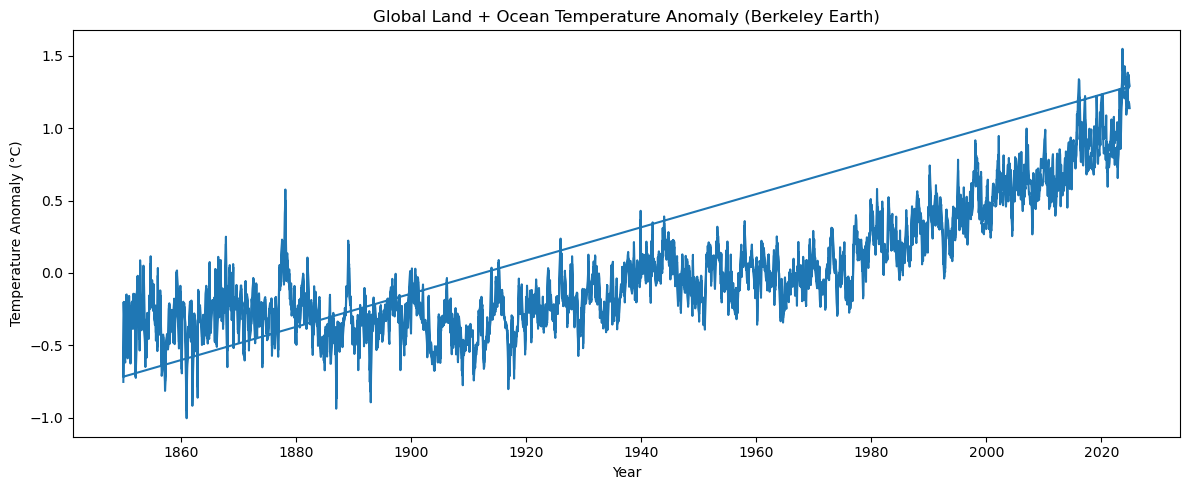

In [4]:
# ---- Basic Plot ----
plt.figure(figsize=(12, 5))
plt.plot(df_data["Date"], df_data["month_Anomaly"])
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Global Land + Ocean Temperature Anomaly (Berkeley Earth)")
plt.tight_layout()
plt.show()

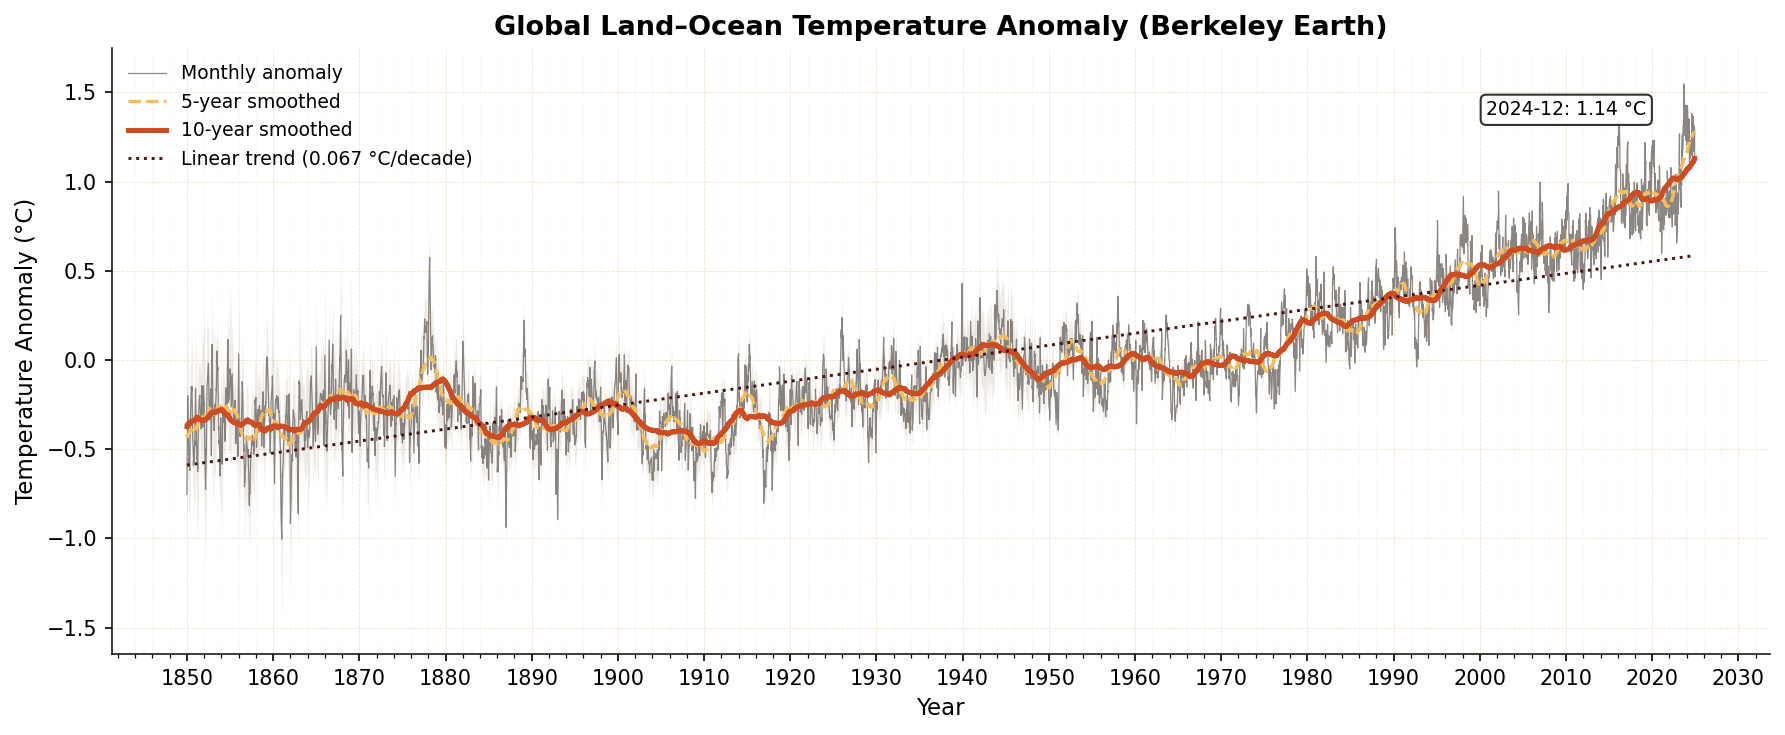

Figure saved to: Figrue/1temperature_anomaly_publication.png


In [5]:
# ---------------------------
# Data preparation (unchanged)
# ---------------------------
df = df_data.copy()

if not np.issubdtype(df["Date"].dtype, np.datetime64):
    df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

# Smoothing windows (years)
window_years_5 = 5
window_years_10 = 10
w5 = int(window_years_5 * 12)
w10 = int(window_years_10 * 12)

df["smoothed_5y"] = df["month_Anomaly"].rolling(
    window=w5, center=True, min_periods=int(w5 / 3)
).mean()

df["smoothed_10y"] = df["month_Anomaly"].rolling(
    window=w10, center=True, min_periods=int(w10 / 3)
).mean()

# Linear trend (°C / decade)
x_years = df["Date"].dt.year + (df["Date"].dt.month - 1) / 12.0
mask = ~df["month_Anomaly"].isna()
coeffs = np.polyfit(x_years[mask], df.loc[mask, "month_Anomaly"], 1)
slope_per_decade = coeffs[0] * 10
trend_line = np.poly1d(coeffs)(x_years)

# Numeric arrays
x_dates = df["Date"].to_numpy()
y = pd.to_numeric(df["month_Anomaly"], errors="coerce").to_numpy()
unc = pd.to_numeric(df["Monthly_Unc"], errors="coerce").to_numpy() if "Monthly_Unc" in df.columns else None

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12, 5), dpi=150)
ax = plt.gca()

# Monthly anomaly (background signal)
valid = np.isfinite(y)
ax.plot(
    x_dates[valid], y[valid],
    color="#5E5752FF",
    linewidth=0.6,
    alpha=0.7,
    label="Monthly anomaly"
)

# Uncertainty shading
if unc is not None:
    upper = y + unc
    lower = y - unc
    valid_unc = np.isfinite(upper) & np.isfinite(lower) & valid
    if valid_unc.any():
        ax.fill_between(
            x_dates[valid_unc],
            lower[valid_unc],
            upper[valid_unc],
            color="#CCC2B5FF",
            alpha=0.35,
            linewidth=0
        )

# 5-year smoothed
y5 = pd.to_numeric(df["smoothed_5y"], errors="coerce").to_numpy()
valid5 = np.isfinite(y5)
ax.plot(
    x_dates[valid5], y5[valid5],
    color="#F5BC5CFF",
    linewidth=1.6,
    linestyle="--",
    label="5-year smoothed"
)

# 10-year smoothed (primary)
y10 = pd.to_numeric(df["smoothed_10y"], errors="coerce").to_numpy()
valid10 = np.isfinite(y10)
ax.plot(
    x_dates[valid10], y10[valid10],
    color="#CC4C24FF",
    linewidth=2.4,
    label="10-year smoothed"
)

# Linear trend
ax.plot(
    x_dates[valid],
    trend_line[valid],
    color="#491212FF",
    linewidth=1.4,
    linestyle=":",
    label=f"Linear trend ({slope_per_decade:.3f} °C/decade)"
)

# ---------------------------
# Formatting
# ---------------------------
ax.xaxis.set_major_locator(YearLocator(base=10))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.xaxis.set_minor_locator(YearLocator(base=2))

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=11)
ax.set_title(
    "Global Land–Ocean Temperature Anomaly (Berkeley Earth)",
    fontsize=13,
    weight="bold"
)

ax.grid(which="major", linestyle="--", linewidth=0.4, alpha=0.6, color="#E8CFABFF")
ax.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.4, color="#E8CFABFF")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#171E15FF")
ax.spines["bottom"].set_color("#171E15FF")
ax.tick_params(axis="both", labelsize=10)

ax.legend(frameon=False, fontsize=9, loc="upper left")

# Annotate latest value
last_idx = np.where(np.isfinite(y))[0][-1]
last_date = pd.to_datetime(x_dates[last_idx])
last_anom = y[last_idx]

ax.annotate(
    f"{last_date.strftime('%Y-%m')}: {last_anom:.2f} °C",
    xy=(last_date, last_anom),
    xytext=(-100, 20),
    textcoords="offset points",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="#171E15FF",
        alpha=0.9
    )
)

# ---------------------------
# Save
# ---------------------------
outname = "Figrue/1temperature_anomaly_publication.png"
plt.tight_layout()
plt.savefig(outname, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {outname}")


In [6]:
# --- Ensure datetime ---
df['Date'] = pd.to_datetime(df['Date'])

# --- User-defined period ---
start_date = "2016-01-01"
end_date   = "2022-12-01"

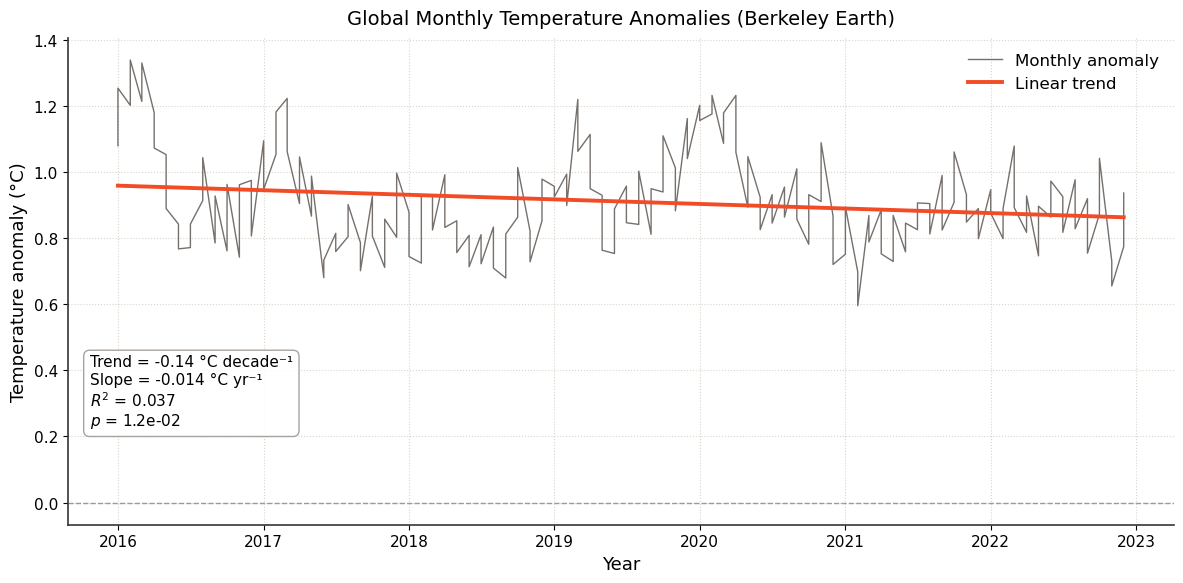

In [7]:
# --- Colour palette ---
palette = {
    "dark_red": "#491212FF",
    "bright_orange": "#F24C27FF",
    "mid_grey": "#5E5752FF",
    "light_grey": "#9F9994FF",
    "pale_grey": "#CCC2B5FF",
    "dark_grey": "#32373AFF",
    "near_black": "#171E15FF",
}

df_sel = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# --- Regression ---
x_days = df_sel['Date'].map(pd.Timestamp.toordinal).values
y = df_sel['month_Anomaly'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x_days, y)
trend = slope * x_days + intercept

# --- Unit conversions ---
slope_per_year = slope * 365.25
trend_per_decade = slope_per_year * 10
r_squared = r_value ** 2

# --- Figure setup ---
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot data ---
ax.plot(
    df_sel['Date'],
    y,
    color=palette["mid_grey"],
    linewidth=1.0,
    alpha=0.85,
    label="Monthly anomaly"
)

# --- Regression line ---
ax.plot(
    df_sel['Date'],
    trend,
    color=palette["bright_orange"],
    linewidth=2.8,
    label="Linear trend"
)

# --- Zero line ---
ax.axhline(
    0,
    color=palette["light_grey"],
    linestyle="--",
    linewidth=1.0
)

# --- Labels & title ---
ax.set_xlabel("Year")
ax.set_ylabel("Temperature anomaly (°C)")
ax.set_title(
    "Global Monthly Temperature Anomalies (Berkeley Earth)",
    pad=10
)

# --- Grid ---
ax.grid(
    True,
    linestyle=":",
    linewidth=0.8,
    color=palette["pale_grey"],
    alpha=0.7
)

# --- Spines ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(palette["dark_grey"])
ax.spines["bottom"].set_color(palette["dark_grey"])

# --- Legend ---
ax.legend(frameon=False, loc="upper right")

# --- Regression parameter text ---
param_text = (
    f"Trend = {trend_per_decade:.2f} °C decade⁻¹\n"
    # f"Trend = {trend_per_decade:.2f} °C decade$^{{-1}}$\n"
    f"Slope = {slope_per_year:.3f} °C yr⁻¹\n"
    f"$R^2$ = {r_squared:.3f}\n"
    f"$p$ = {p_value:.1e}"
)

ax.text(
    0.02, 0.35,
    param_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor=palette["light_grey"],
        alpha=0.9
    )
)

# --- Layout & save ---
plt.tight_layout()

# Recommended for publication:
# plt.savefig("berkeley_temperature_trend_with_params.pdf")
plt.savefig("Figrue/1berkeley_temperature_trend_with_params.png")
# plt.savefig("berkeley_temperature_trend_with_params.svg")

plt.show()

# Spurious correlations

Number of websites on the internet vs Total wind power generated globally  
ref: https://tylervigen.com/spurious/correlation/5236_number-of-websites-on-the-internet_correlates-with_total-wind-power-generated-globally#datadetail

In [8]:
# ---- Data ----
years = list(range(1991, 2019))

websites = [
    1, 10, 130, 2738, 23500, 257601, 1117260, 2410070, 3177450, 17087200,
    29254400, 38760400, 40912300, 51611600, 64780600, 85507300, 121893000,
    172339000, 238028000, 206957000, 346004000, 697089000, 672985000,
    968882000, 863106000, 1045530000, 1766930000, 1630320000
]

wind_power = [
    4.09695, 4.61206, 5.55793, 7.28441, 7.93552, 9.28889, 12.134, 16.1075,
    21.2765, 31.3317, 38.3652, 52.7331, 64.5029, 84.6314, 104.241, 133.42,
    171.303, 221.363, 277.775, 339.401, 435.106, 521.503, 645.078, 717.25,
    827.435, 957.251, 1127.11, 1263.52
]

data = pd.DataFrame({
    "Websites": websites,
    "Wind Power (Billion kWh)": wind_power
})

# ---- Function ----
def calculate_correlation(array1, array2):
    correlation, p_value = stats.pearsonr(array1, array2)
    r_squared = correlation**2
    return correlation, r_squared, p_value

# ---- Convert lists to numpy arrays ----
array_1 = np.array(websites)
array_2 = np.array(wind_power)

# ---- Names for display ----
array_1_name = "Number of websites on the internet"
array_2_name = "Total wind power generated globally"

# ---- Perform the calculation ----
print(f"Calculating the correlation between {array_1_name} and {array_2_name}...")
correlation, r_squared, p_value = calculate_correlation(array_1, array_2)

# ---- Print results ----
print("Correlation Coefficient:", correlation)
print("R-squared:", r_squared)
print("P-value:", p_value)


Calculating the correlation between Number of websites on the internet and Total wind power generated globally...
Correlation Coefficient: 0.9784944131600884
R-squared: 0.9574513165855059
P-value: 2.3689343033351033e-19


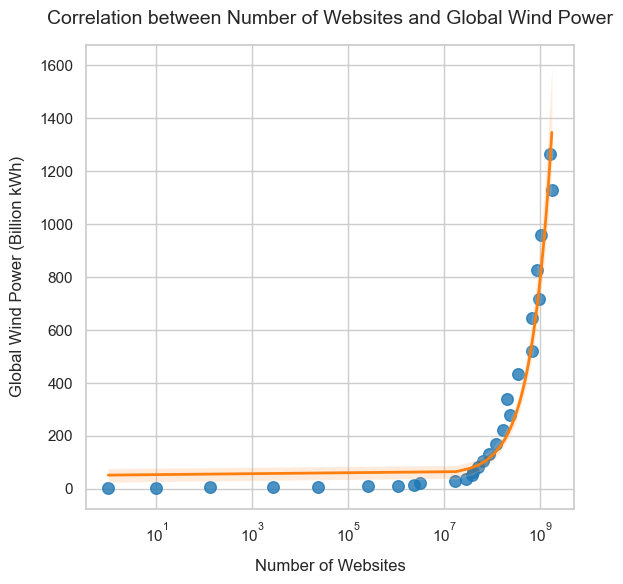

In [10]:
# ---- Set style ----
sns.set_theme(style="whitegrid")  # modern clean grid
plt.figure(figsize=(6, 6))

# ---- Scatter + regression ----
sns.regplot(
    x="Websites",
    y="Wind Power (Billion kWh)",
    data=data,
    scatter_kws={"color": "#1f77b4", "s": 70},  # blue points
    line_kws={"color": "#ff7f0e", "linewidth": 2},  # orange line
    ci=95
)

# ---- Labels & title ----
plt.xlabel("Number of Websites", fontsize=12, labelpad=10)
plt.ylabel("Global Wind Power (Billion kWh)", fontsize=12, labelpad=10)
plt.title("Correlation between Number of Websites and Global Wind Power", fontsize=14, pad=15)
plt.title("Correlation between Number of Websites and Global Wind Power", fontsize=14, pad=15)
# 
# Optional: log scale for websites
plt.xscale("log")

plt.savefig("Figrue/2Spurious_correlations.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [11]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    rc={
        "axes.edgecolor": "#171E15FF",
        "grid.color": "#CCC2B5FF",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.family": "sans-serif"
    }
)

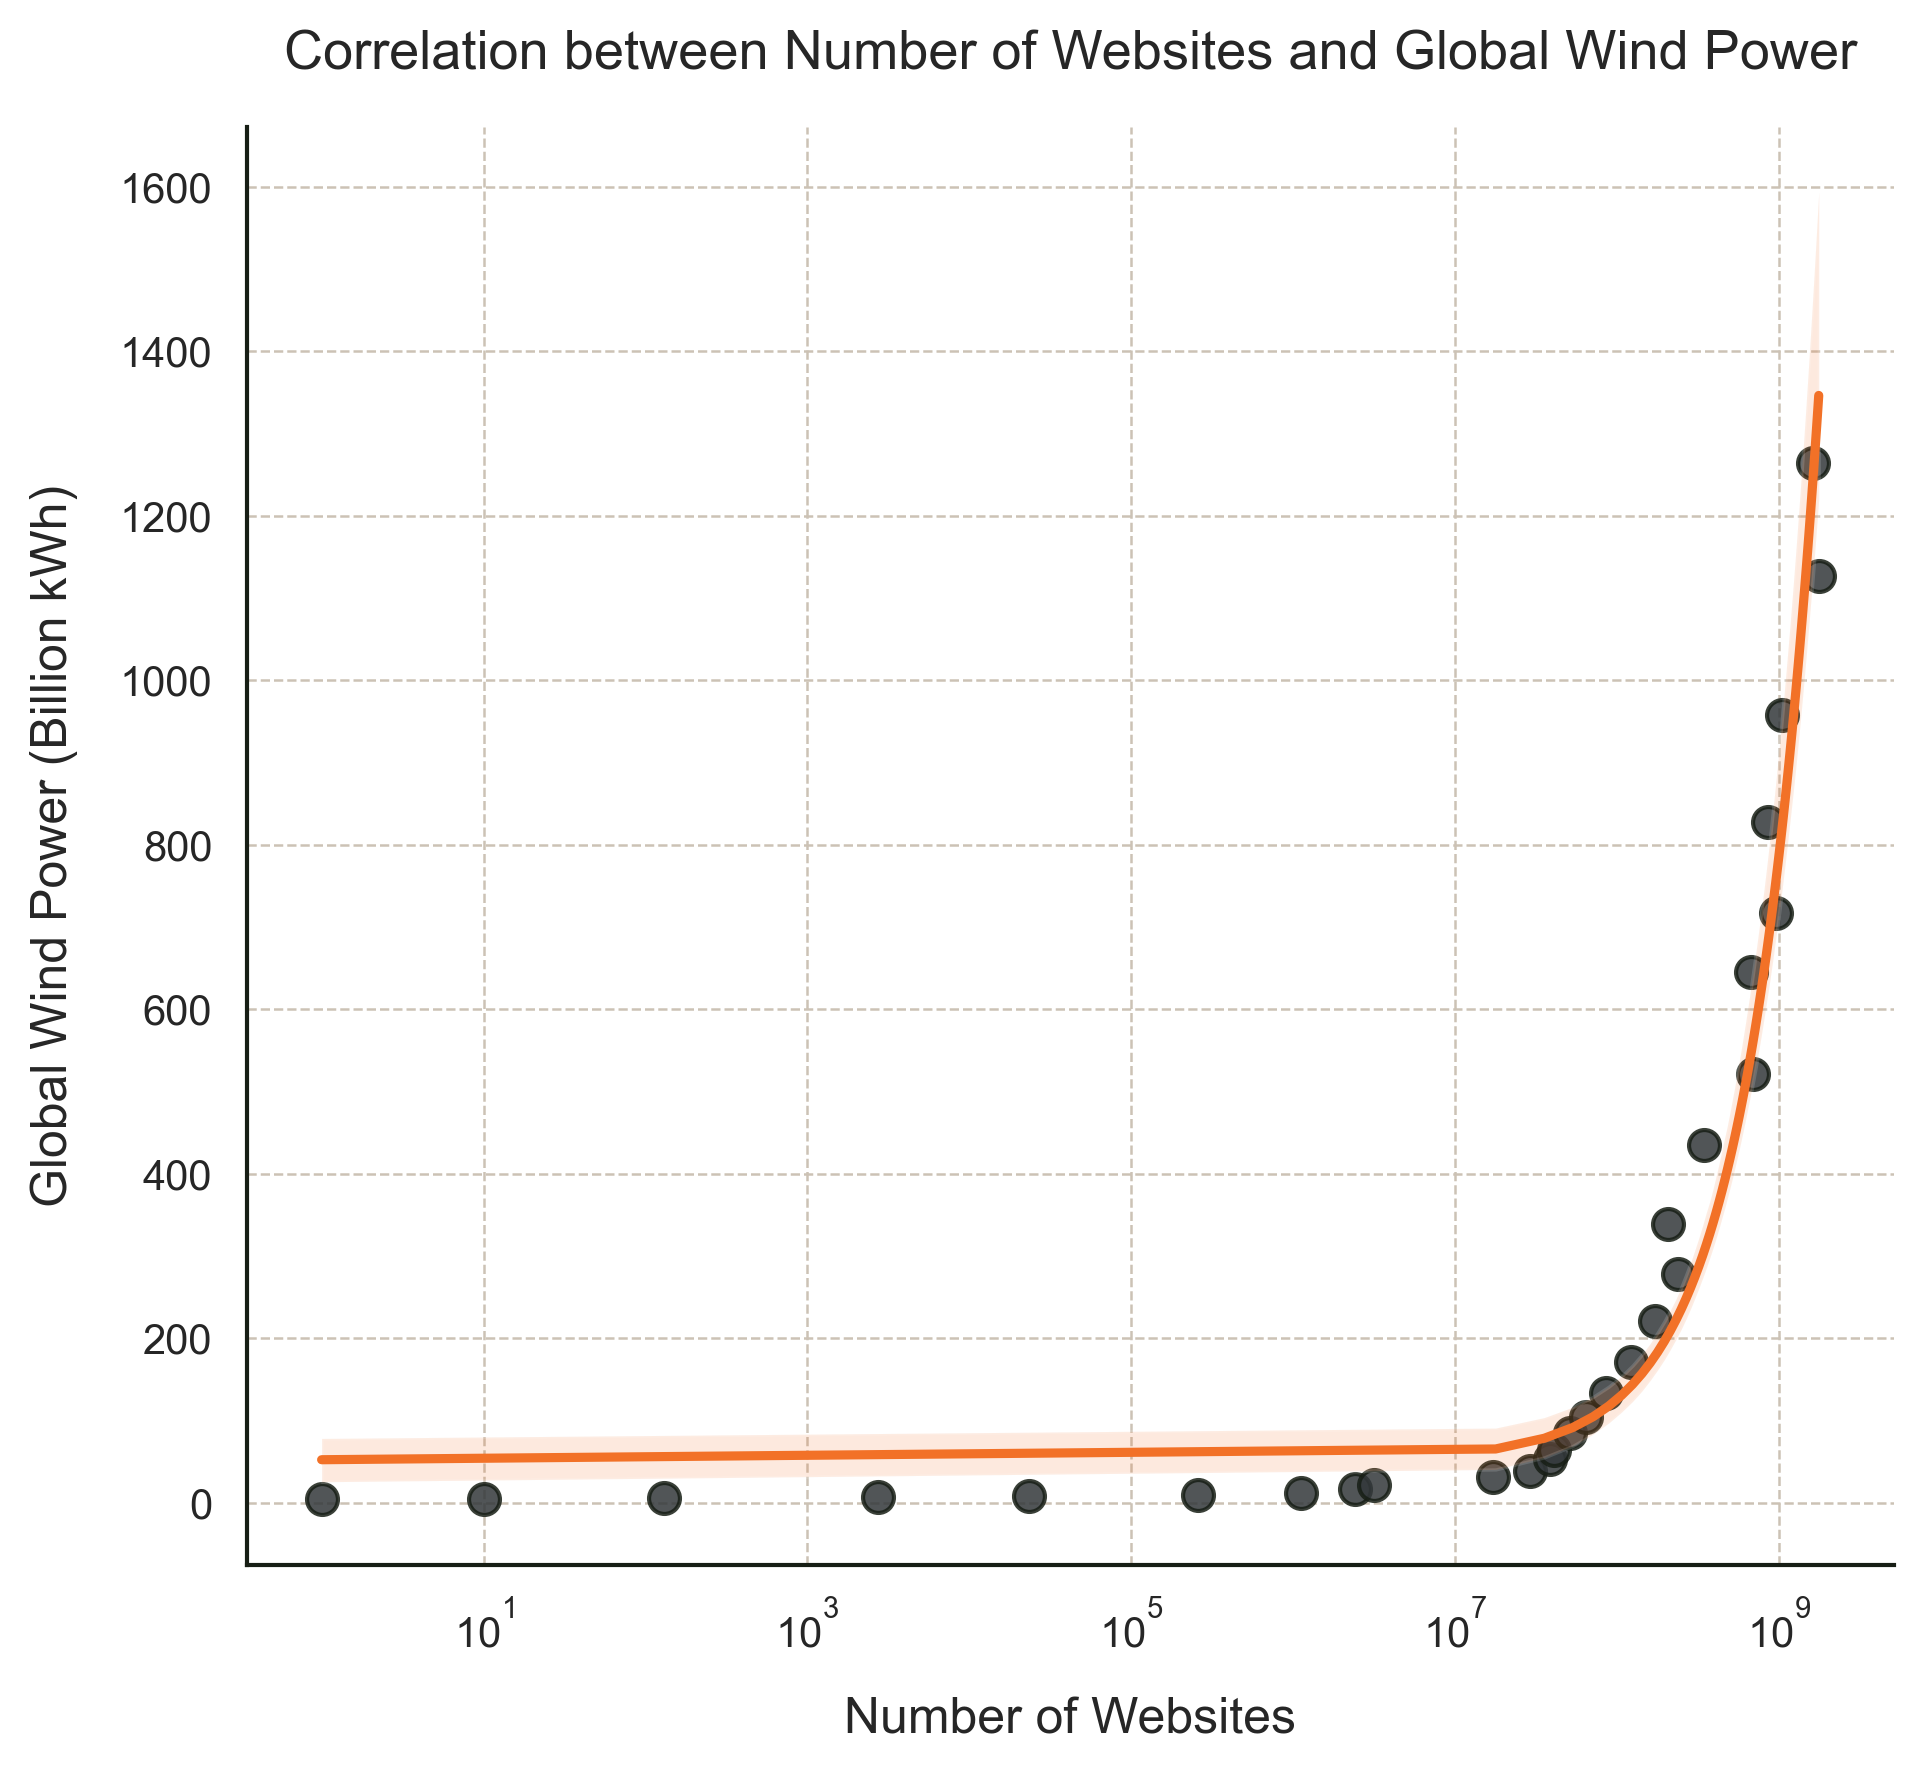

In [12]:
# --------------------------- Log Figure ---------------------------
plt.figure(figsize=(6.5, 6), dpi=300)
ax = plt.gca()

sns.regplot(
    x="Websites",
    y="Wind Power (Billion kWh)",
    data=data,
    ci=95,
    scatter_kws={
        "s": 55,
        "alpha": 0.85,
        "color": "#32373AFF",
        "edgecolor": "#171E15FF",
        # "linewidth": 0.4
    },
    line_kws={
        "color": "#F27127FF",
        "linewidth": 2.2
    },
    ax=ax
)

# --------------------------- Labels & title ---------------------------
ax.set_xlabel("Number of Websites", labelpad=10)
ax.set_ylabel("Global Wind Power (Billion kWh)", labelpad=10)
ax.set_title(
    "Correlation between Number of Websites and Global Wind Power",
    pad=14
)

# Optional: log scale (kept explicit and documented)
ax.set_xscale("log")

# --------------------------- Clean spines ---------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# --------------------------- Save ---------------------------
plt.savefig(
    "Figrue/2Spurious_correlations.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

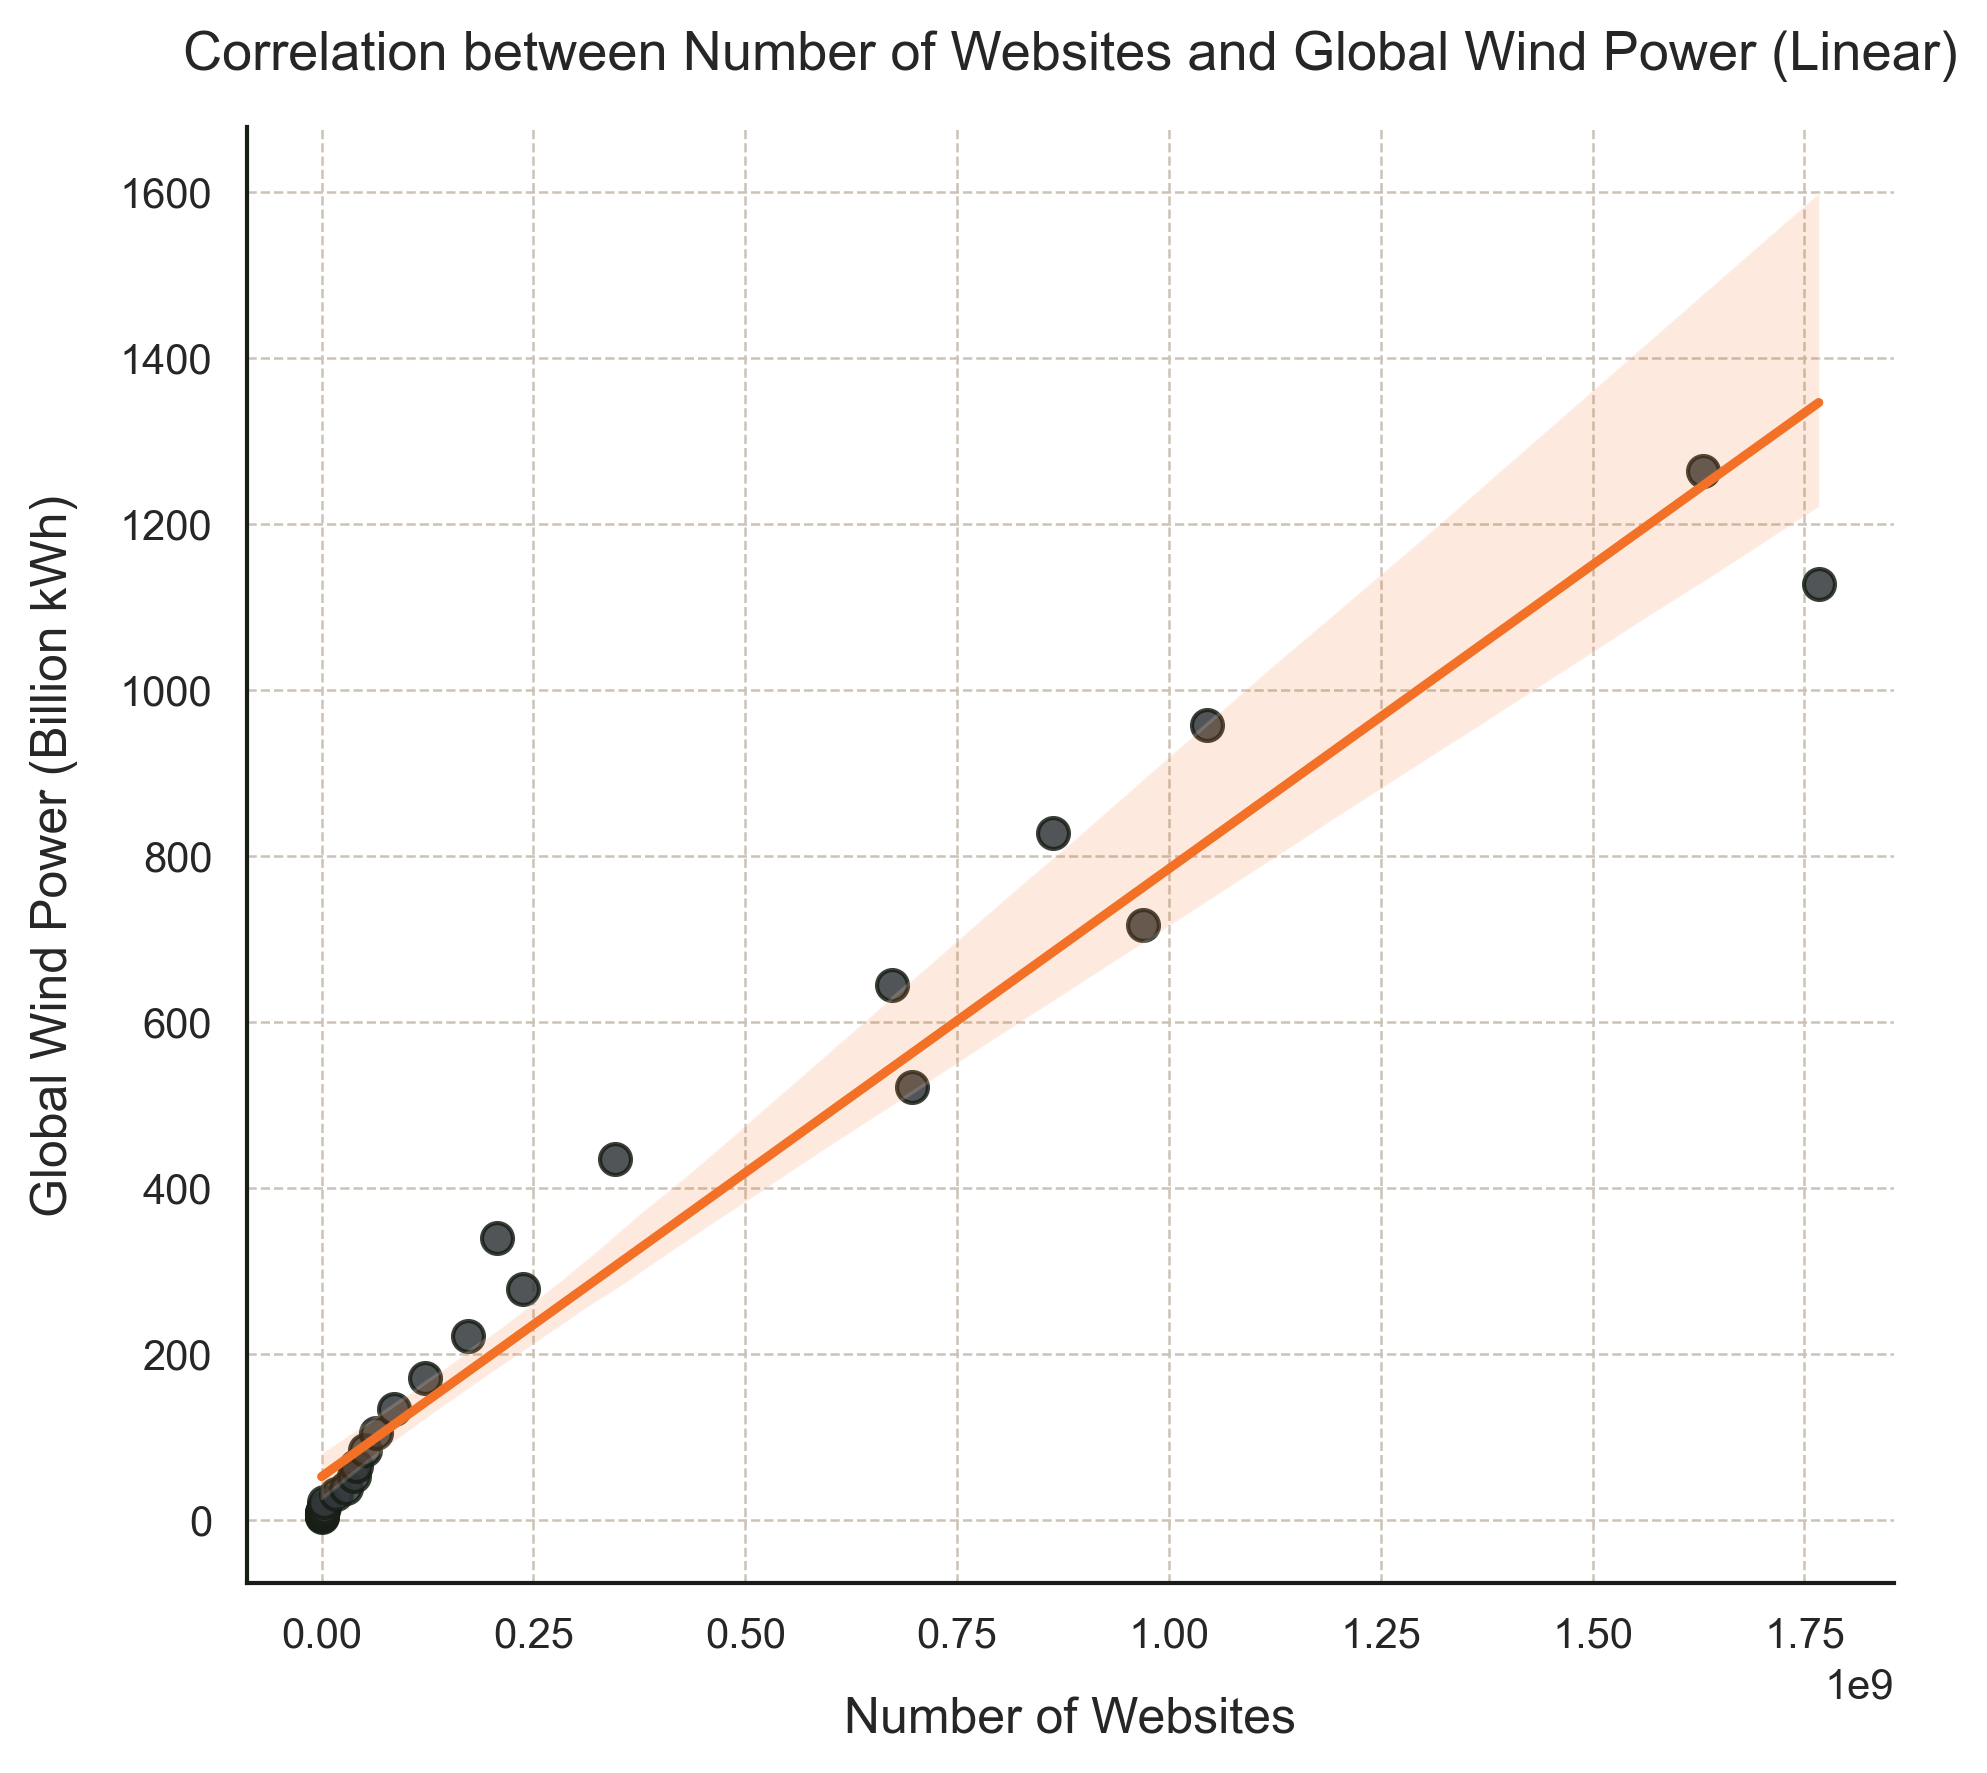

In [13]:
# --------------------------- Liner Figure ---------------------------
plt.figure(figsize=(6.5, 6), dpi=300)
ax = plt.gca()

# --------------------------- Scatter + regression (NO log scale) ---------------------------
sns.regplot(
    x="Websites",
    y="Wind Power (Billion kWh)",
    data=data,
    ci=95,
    scatter_kws={
        "s": 55,
        "alpha": 0.85,
        "color": "#32373AFF",      # neutral dark gray
        "edgecolor": "#171E15FF",
    },
    line_kws={
        "color": "#F27127FF",      # warm orange
        "linewidth": 2.2
    },
    ax=ax
)

# --------------------------- Labels & title ---------------------------
ax.set_xlabel("Number of Websites", labelpad=10)
ax.set_ylabel("Global Wind Power (Billion kWh)", labelpad=10)
ax.set_title(
    "Correlation between Number of Websites and Global Wind Power (Linear)",
    pad=14
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# --------------------------- Save ---------------------------
plt.savefig(
    "Figrue/2Spurious_correlations_linear.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

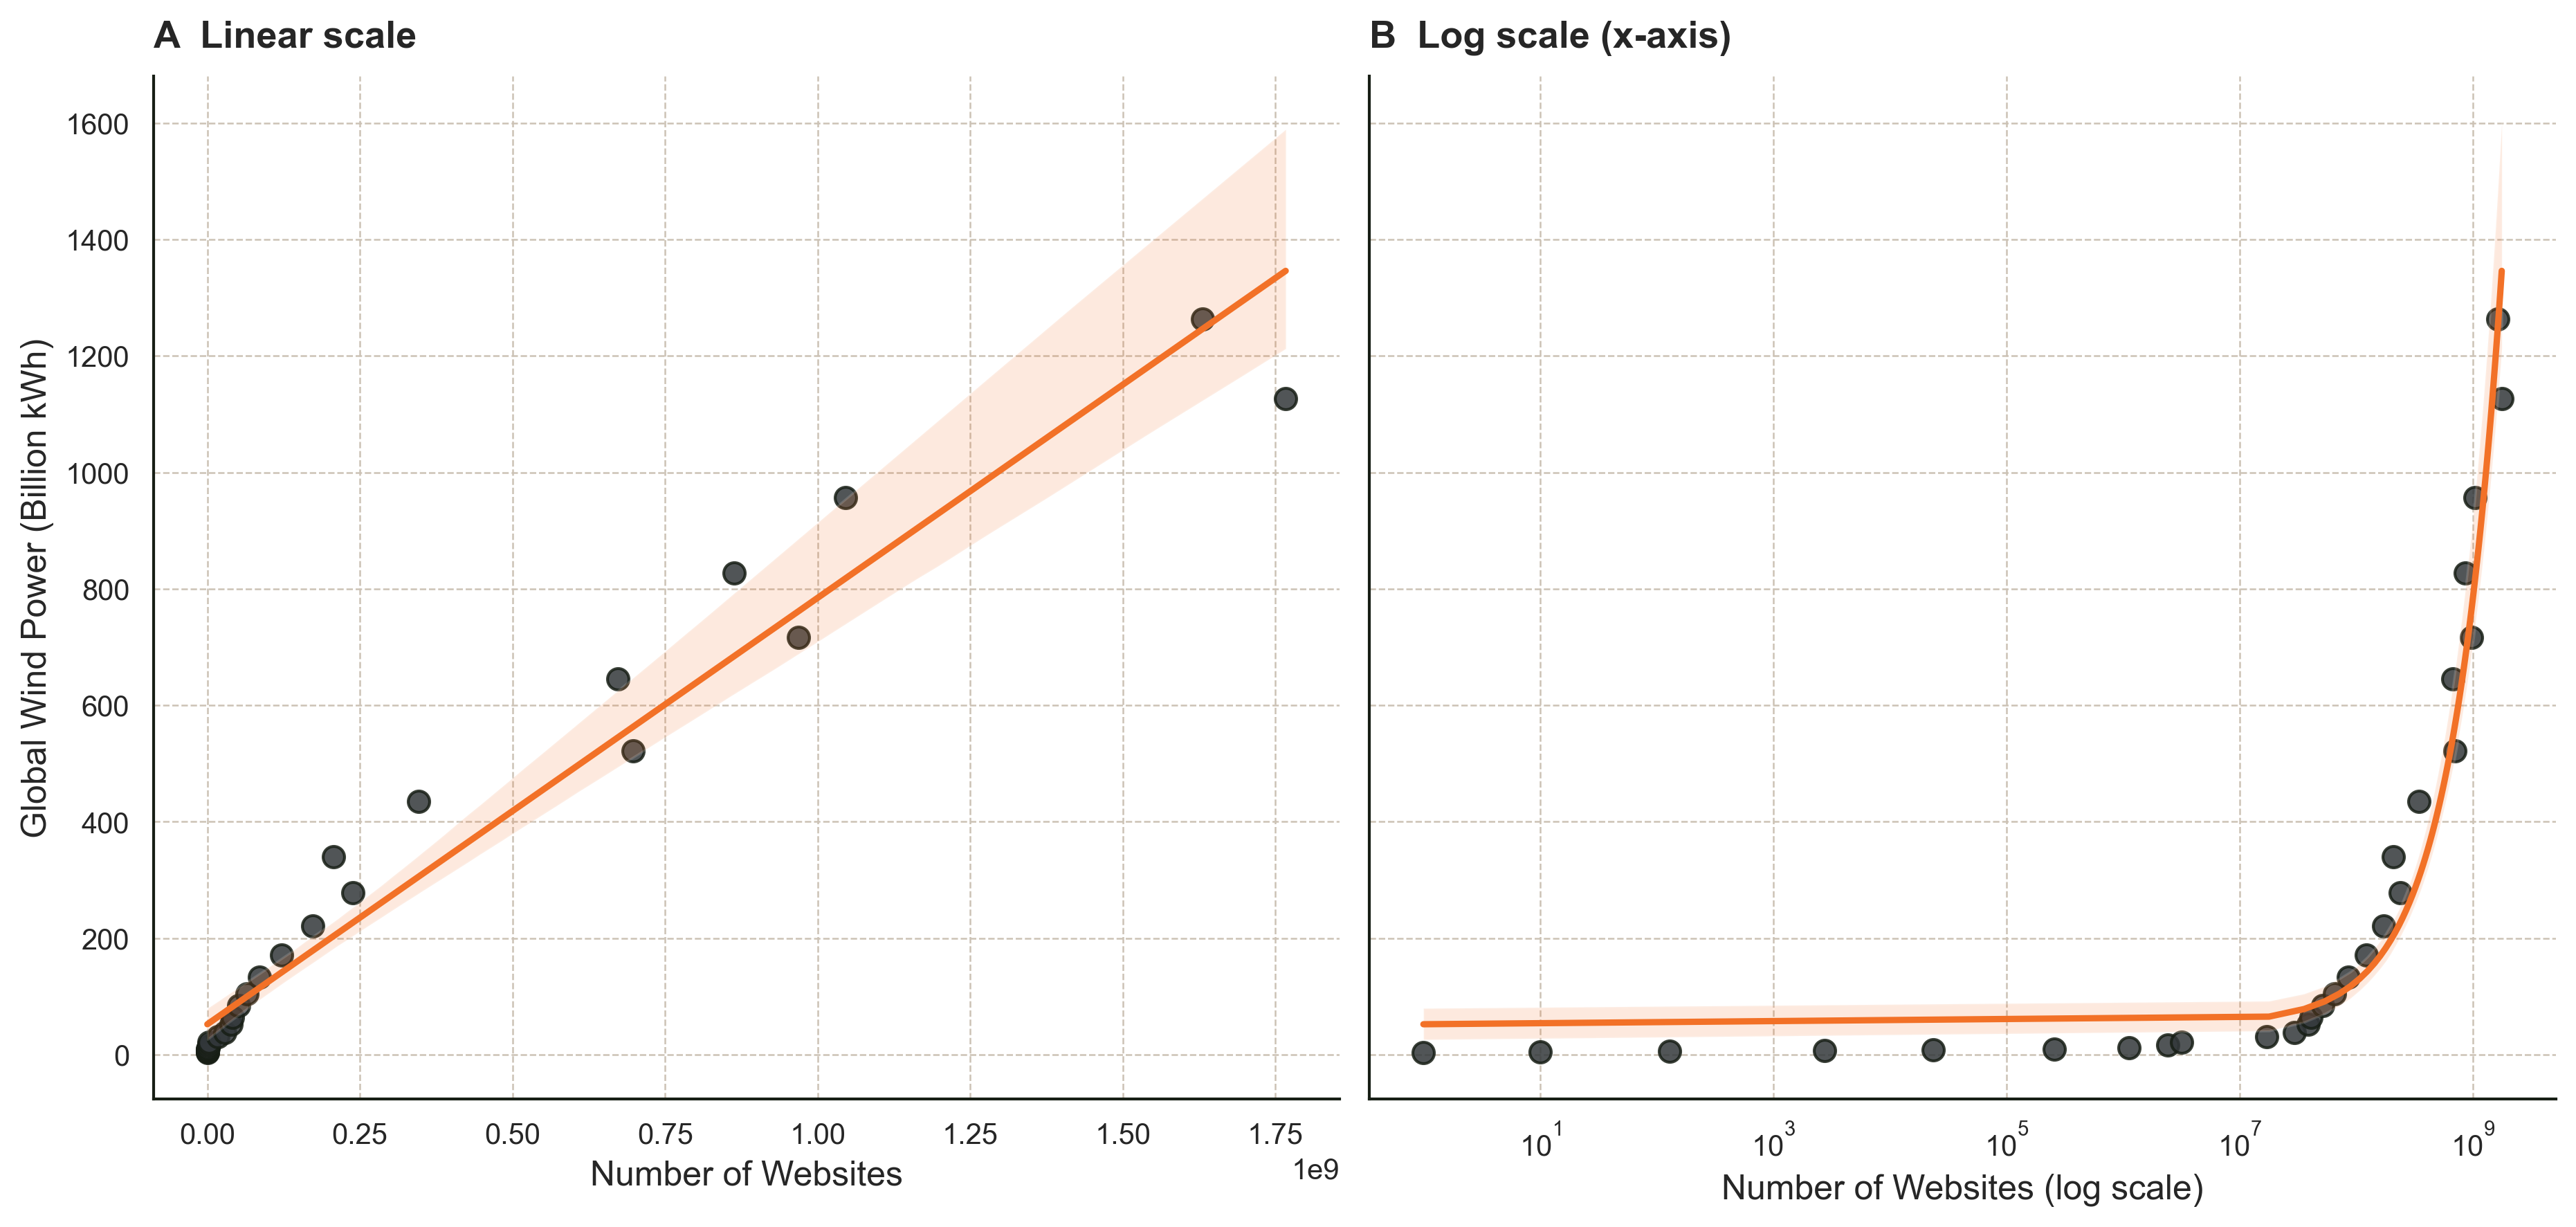

In [14]:
# --------------------------- Figure with two panels ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 6), dpi=300, sharey=True)

# Common plotting arguments
scatter_kws = {
    "s": 55,
    "alpha": 0.85,
    "color": "#32373AFF",
    "edgecolor": "#171E15FF",
}

line_kws = {
    "color": "#F27127FF",
    "linewidth": 2.2
}

# ---------------------------
# Panel A: Linear scale
# ---------------------------
sns.regplot(
    x="Websites",
    y="Wind Power (Billion kWh)",
    data=data,
    ci=95,
    scatter_kws=scatter_kws,
    line_kws=line_kws,
    ax=axes[0]
)

axes[0].set_title("A  Linear scale", loc="left", pad=10, fontweight="bold")
axes[0].set_xlabel("Number of Websites")
axes[0].set_ylabel("Global Wind Power (Billion kWh)")

# ---------------------------
# Panel B: Log scale
# ---------------------------
sns.regplot(
    x="Websites",
    y="Wind Power (Billion kWh)",
    data=data,
    ci=95,
    scatter_kws=scatter_kws,
    line_kws=line_kws,
    ax=axes[1]
)

axes[1].set_xscale("log")
axes[1].set_title("B  Log scale (x-axis)", loc="left", pad=10, fontweight="bold")
axes[1].set_xlabel("Number of Websites (log scale)")
axes[1].set_ylabel("")

# ---------------------------
# Clean spines
# ---------------------------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

# ---------------------------
# Save
# ---------------------------
plt.savefig(
    "Figrue/2Spurious_correlations_two_panel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# False Causality

In [15]:
# --------------------------- Generate synthetic data ---------------------------
np.random.seed(42)
n = 100

x = np.sort(np.random.uniform(0, 550, n))
noise = np.random.normal(0, 30 + 0.03 * x, n)
y = 0.5 * x + 20 + noise
y = np.clip(y, 0, None)

df = pd.DataFrame({
    "Ice Cream Sales (thousands)": x,
    "Drownings": y
})

# ---------------------------
# Statistics
# ---------------------------
slope, intercept = np.polyfit(x, y, 1)
r, p = pearsonr(x, y)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_fit + intercept

resid = y - (slope * x + intercept)
mse = np.sum(resid**2) / (n - 2)
x_mean = x.mean()
Sxx = np.sum((x - x_mean)**2)
se_pred = np.sqrt(mse * (1 + 1/n + (x_fit - x_mean)**2 / Sxx))

upper = y_fit + 2 * se_pred
lower = y_fit - 2 * se_pred


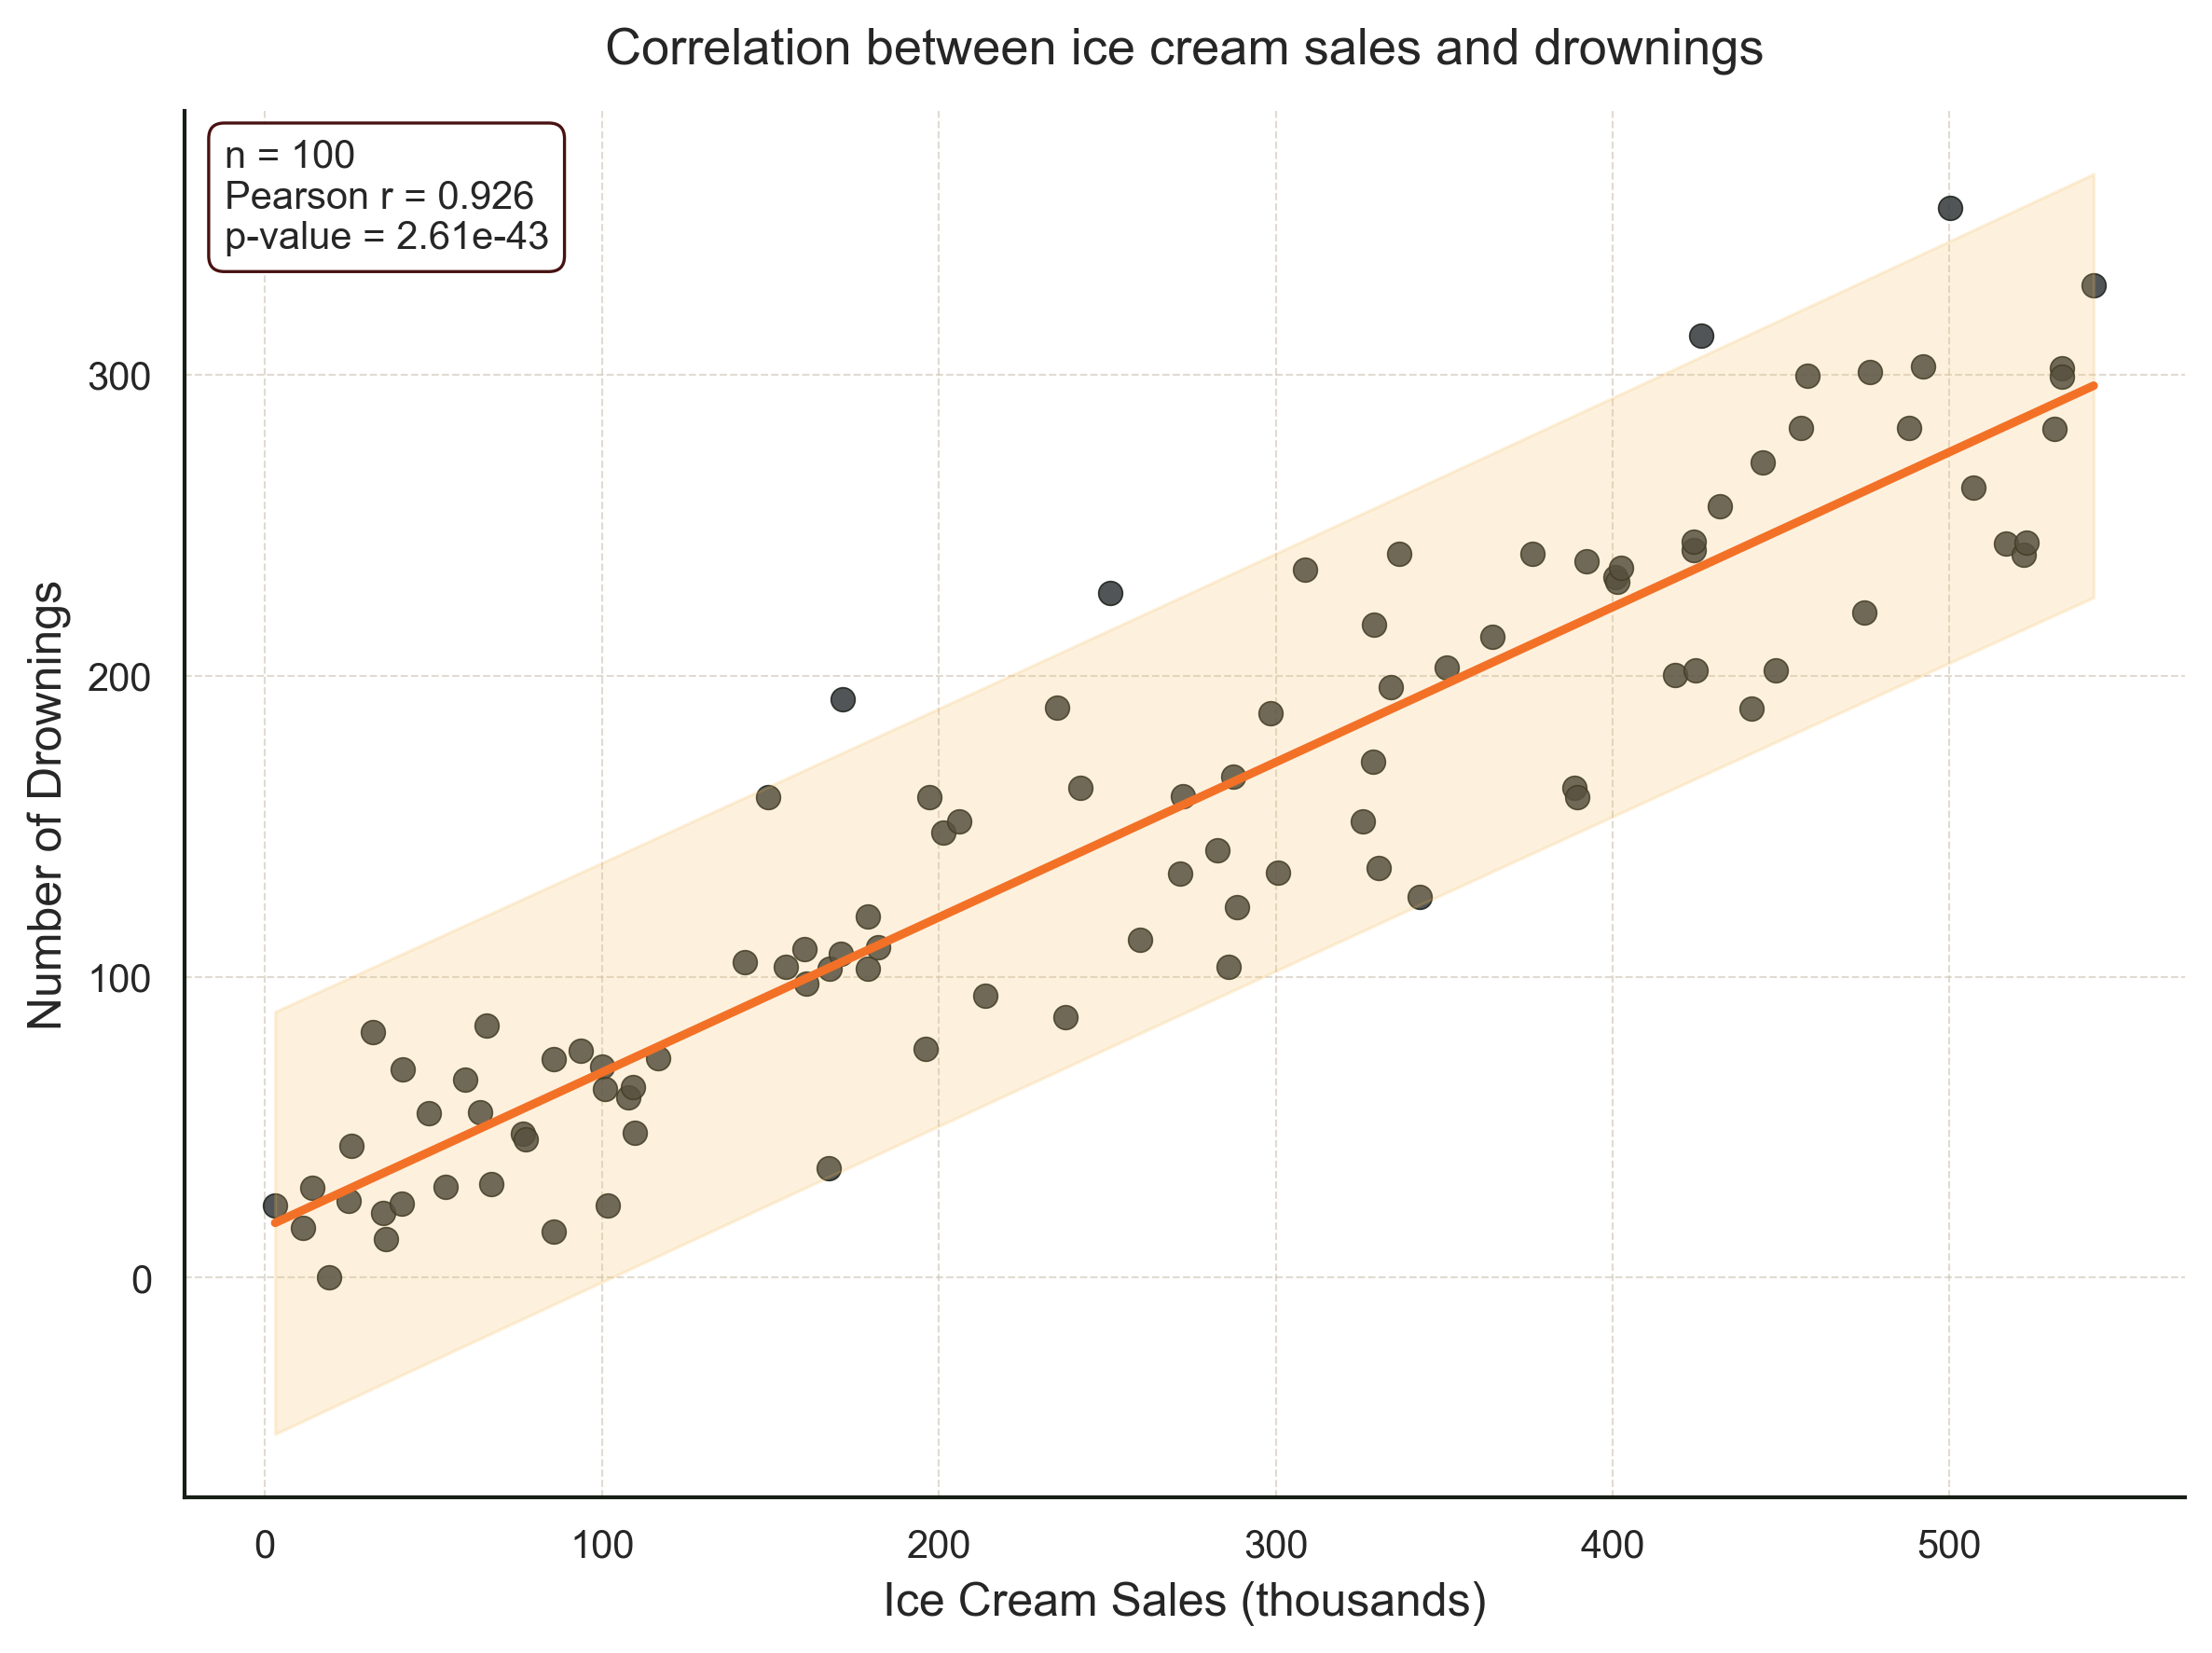

In [16]:
# --------------------------- Plot styling ---------------------------
plt.figure(figsize=(8, 6), dpi=300)
ax = plt.gca()

# Scatter
ax.scatter(
    x, y,
    s=38,
    alpha=0.85,
    edgecolor="#171E15FF",
    linewidth=0.4,
    color="#32373AFF"
)

# Regression line
ax.plot(
    x_fit, y_fit,
    linewidth=2.2,
    color="#F27127FF",
    label="OLS regression"
)

# Prediction band
ax.fill_between(
    x_fit, lower, upper,
    color="#F5BC5CFF",
    alpha=0.2,
    label="95% prediction interval"
)

# Labels
ax.set_xlabel("Ice Cream Sales (thousands)", fontsize=12)
ax.set_ylabel("Number of Drownings", fontsize=12)
ax.set_title(
    "Correlation between ice cream sales and drownings",
    fontsize=13,
    pad=12
)

# Annotation
stats_text = (
    f"n = {n}\n"
    f"Pearson r = {r:.3f}\n"
    f"p-value = {p:.2e}"
)

ax.text(
    0.02, 0.98,
    stats_text,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="#491212FF",
        linewidth=0.8
    )
)

# Grid & spines
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("Figrue/3False_Causality.png", dpi=300, bbox_inches="tight")

plt.show()